# Results: coeffs from optimisation after DEAP

Visually inspect the admissions coefficients from the optimisation results. Calculate r-squared values to decide which coefficients are the best.

__Inputs:__

+ Optimised coefficients from `minimize`
+ Optimised coefficients from simulated annealing
+ MSOA-level admissions and population data for calculating admissions from resulting coefficients.

__Results:__

+ Data: final admissions coefficients.
  + One coefficient for each combination of age band and deprivation quantile, and one set of coefficients for: the best option; minimal values; maximal values. 

__Method:__

Compare the results from the optimisation function with the input coefficients. Scatter the input and output coefficients to check how much they have changed.

Calculate r-squared values for the simulated annealing results. Use the set with the best r-squared as the final coefficients.

__Conclusion:__

The results don't all converge on a similar set of values from all 100 starting points.
Use the result with the best r-squared as the chosen coefficients,
and use the range of values as an idea of accuracy.
Round the results to 1 (2) significant figures because of this range of values. Can't justify being any more precise when clearly all of them give pretty good results.

## Code setup

In [1]:
import os
import polars as pl
from scipy.optimize import minimize, basinhopping
import numpy as np
import matplotlib.pyplot as plt

## Load starting coeffs

from best DEAP results

Check results:

In [2]:
df_coeffs_init = pl.read_csv(os.path.join('genetic_algorithms', 'outputs', 'post_deap_inputs_for_opt.csv'))

df_coeffs_init

coeff_combo,age_less65_q00,age_65_q00,age_70_q00,age_75_q00,age_over80_q00,age_less65_q02,age_65_q02,age_70_q02,age_75_q02,age_over80_q02,age_less65_q04,age_65_q04,age_70_q04,age_75_q04,age_over80_q04,age_less65_q06,age_65_q06,age_70_q06,age_75_q06,age_over80_q06,age_less65_q08,age_65_q08,age_70_q08,age_75_q08,age_over80_q08
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""randomseed36""",0.000521,0.003257,0.004489,0.007206,0.014286,0.0004488,0.002908,0.0041085,0.0066055,0.012806,0.000368,0.002644,0.003735,0.006005,0.011558,0.0003672,0.0023796,0.003735,0.005405,0.010368,0.0003264,0.0023796,0.002988,0.004804,0.01024
"""randomseed95""",0.000542,0.003472,0.004661,0.007056,0.014124,0.000475,0.002908,0.0041085,0.006095,0.012679,0.000371,0.002612,0.003522,0.006005,0.011558,0.000353,0.0023796,0.0033615,0.005831,0.0104022,0.0002856,0.002224,0.0033615,0.004876,0.0104022
"""randomseed73""",0.0005304,0.0034372,0.004549,0.007206,0.01387,0.000408,0.002937,0.0041085,0.006642,0.012945,0.000405,0.002567,0.003735,0.005705,0.011558,0.000366,0.002567,0.003634,0.005405,0.0104022,0.0003264,0.002123,0.002988,0.004984,0.0104022
"""randomseed52""",0.0005304,0.003093,0.004482,0.007206,0.01387,0.0004488,0.003093,0.0041085,0.006413,0.0127138,0.000368,0.002644,0.003735,0.005987,0.011558,0.0003672,0.0023796,0.003332,0.005657,0.010633,0.0003264,0.002353,0.003332,0.004618,0.0104022
"""randomseed10""",0.00053,0.003593,0.004732,0.007206,0.01387,0.000406,0.002824,0.004273,0.0066055,0.0127138,0.00038,0.002644,0.003735,0.006005,0.011558,0.00038,0.0023796,0.0033615,0.005405,0.0104022,0.000347,0.002197,0.002988,0.004804,0.0104022
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""randomseed09""",0.000482,0.0031728,0.004482,0.00717,0.01402,0.000461,0.002644,0.003955,0.006017,0.0127138,0.000378,0.002644,0.003627,0.006005,0.011558,0.000359,0.002644,0.003515,0.005405,0.011073,0.000359,0.0023796,0.0033615,0.005218,0.009709
"""randomseed41""",0.0004896,0.0031728,0.004519,0.00699,0.01387,0.0004488,0.003072,0.004336,0.0066055,0.012968,0.000408,0.002591,0.003735,0.005777,0.011558,0.0003672,0.002488,0.003492,0.005405,0.0104022,0.00032,0.0022474,0.002988,0.005074,0.0104022
"""randomseed82""",0.000495,0.003353,0.004325,0.007206,0.01387,0.000417,0.002797,0.004306,0.005891,0.0127138,0.000408,0.002644,0.003735,0.005891,0.011558,0.0003672,0.0023796,0.003317,0.005405,0.011408,0.000358,0.0023796,0.003317,0.005405,0.009593


Pick out the directory names: 

In [3]:
# best_dirs = df_best_gens.filter(np.round(df_best_gens['r2_all'], 3) == np.round(df_best_gens['r2_all'].max(), 3))['dir'].to_numpy()
best_dirs = df_coeffs_init['coeff_combo'].to_numpy()

Coefficient names:

In [4]:
coeff_names = [
    'age_less65_q00',
    'age_65_q00',
    'age_70_q00',
    'age_75_q00',
    'age_over80_q00',
    'age_less65_q02',
    'age_65_q02',
    'age_70_q02',
    'age_75_q02',
    'age_over80_q02',
    'age_less65_q04',
    'age_65_q04',
    'age_70_q04',
    'age_75_q04',
    'age_over80_q04',
    'age_less65_q06',
    'age_65_q06',
    'age_70_q06',
    'age_75_q06',
    'age_over80_q06',
    'age_less65_q08',
    'age_65_q08',
    'age_70_q08',
    'age_75_q08',
    'age_over80_q08'
]

### Load optimisation results

Minimize:

In [5]:
df_results = pl.read_csv(os.path.join('genetic_algorithms', 'outputs', 'post_deap_multi_optimise_coeffs_results.csv'))

Annealing:

In [6]:
df_ann_results = pl.read_csv(os.path.join('genetic_algorithms', 'outputs', 'post_deap_multi_basinhop_coeffs_results.csv'))

### View minimize results

In [7]:
df_results#[coeff_names]

coeff_combo,message,success,status,nit,nfev,age_less65_q00,age_65_q00,age_70_q00,age_75_q00,age_over80_q00,age_less65_q02,age_65_q02,age_70_q02,age_75_q02,age_over80_q02,age_less65_q04,age_65_q04,age_70_q04,age_75_q04,age_over80_q04,age_less65_q06,age_65_q06,age_70_q06,age_75_q06,age_over80_q06,age_less65_q08,age_65_q08,age_70_q08,age_75_q08,age_over80_q08,r2_q00,r2_q02,r2_q04,r2_q06,r2_q08,r2_all,res
str,str,bool,i64,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""randomseed36""","""Optimization terminated succes…",true,0,484,919,0.0005192,0.0032617,0.0044693,0.0072125,0.014303,0.0004475,0.0029045,0.0041259,0.0065802,0.0127753,0.0003726,0.0026334,0.003739,0.0060131,0.0115346,0.0003669,0.0023906,0.0036742,0.0053775,0.0103747,0.0003285,0.0023827,0.0029625,0.0048042,0.0102899,0.50654,0.58059,0.63808,0.61457,0.61799,0.59565,236.82
"""randomseed95""","""Optimization terminated succes…",true,0,413,816,0.0005406,0.0034739,0.0046714,0.0070021,0.0141007,0.0004745,0.0029085,0.0041088,0.006066,0.0126703,0.0003701,0.0026148,0.0035216,0.0059971,0.0115652,0.0003546,0.002381,0.0033678,0.0058497,0.0104329,0.0002882,0.0022461,0.0033557,0.0048528,0.0104023,0.50611,0.57791,0.63797,0.61532,0.62204,0.59594,236.736
"""randomseed73""","""Optimization terminated succes…",true,0,497,968,0.0005303,0.0034193,0.0045599,0.0072469,0.0139063,0.0004071,0.0029284,0.0041068,0.0066472,0.0129101,0.0004048,0.0025715,0.0037239,0.0057043,0.0115296,0.0003662,0.0025622,0.0036236,0.0054088,0.0104168,0.0003277,0.0021265,0.0029845,0.0049804,0.0103911,0.5064,0.5828,0.63467,0.61523,0.61903,0.59565,236.823
"""randomseed52""","""Optimization terminated succes…",true,0,534,943,0.0005262,0.003107,0.004493,0.007364,0.0138917,0.0004443,0.0030928,0.0040974,0.0063983,0.0127098,0.0003685,0.0026352,0.0037299,0.0059918,0.0115379,0.000366,0.0023783,0.0033358,0.0056568,0.0105916,0.0003291,0.0023512,0.0033175,0.0045887,0.0103687,0.50414,0.58101,0.6384,0.61603,0.61868,0.5958,236.776


Compare with starting values:

In [8]:
df_coeffs_init.filter(df_coeffs_init['coeff_combo'].is_in(df_results['coeff_combo']))

coeff_combo,age_less65_q00,age_65_q00,age_70_q00,age_75_q00,age_over80_q00,age_less65_q02,age_65_q02,age_70_q02,age_75_q02,age_over80_q02,age_less65_q04,age_65_q04,age_70_q04,age_75_q04,age_over80_q04,age_less65_q06,age_65_q06,age_70_q06,age_75_q06,age_over80_q06,age_less65_q08,age_65_q08,age_70_q08,age_75_q08,age_over80_q08
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""randomseed36""",0.000521,0.003257,0.004489,0.007206,0.014286,0.0004488,0.002908,0.0041085,0.0066055,0.012806,0.000368,0.002644,0.003735,0.006005,0.011558,0.0003672,0.0023796,0.003735,0.005405,0.010368,0.0003264,0.0023796,0.002988,0.004804,0.01024
"""randomseed95""",0.000542,0.003472,0.004661,0.007056,0.014124,0.000475,0.002908,0.0041085,0.006095,0.012679,0.000371,0.002612,0.003522,0.006005,0.011558,0.000353,0.0023796,0.0033615,0.005831,0.0104022,0.0002856,0.002224,0.0033615,0.004876,0.0104022
"""randomseed73""",0.0005304,0.0034372,0.004549,0.007206,0.01387,0.000408,0.002937,0.0041085,0.006642,0.012945,0.000405,0.002567,0.003735,0.005705,0.011558,0.000366,0.002567,0.003634,0.005405,0.0104022,0.0003264,0.002123,0.002988,0.004984,0.0104022
"""randomseed52""",0.0005304,0.003093,0.004482,0.007206,0.01387,0.0004488,0.003093,0.0041085,0.006413,0.0127138,0.000368,0.002644,0.003735,0.005987,0.011558,0.0003672,0.0023796,0.003332,0.005657,0.010633,0.0003264,0.002353,0.003332,0.004618,0.0104022


Plot starting vs optimised values:

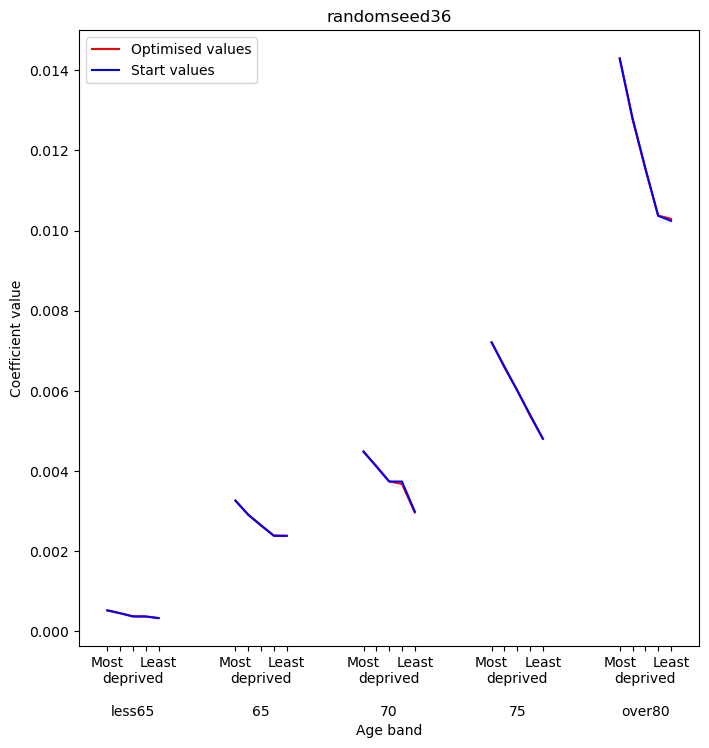

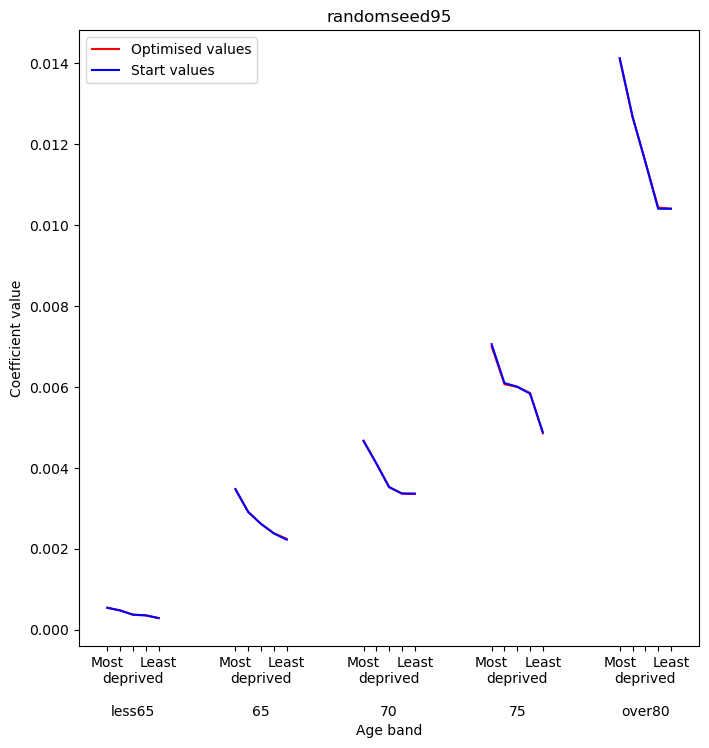

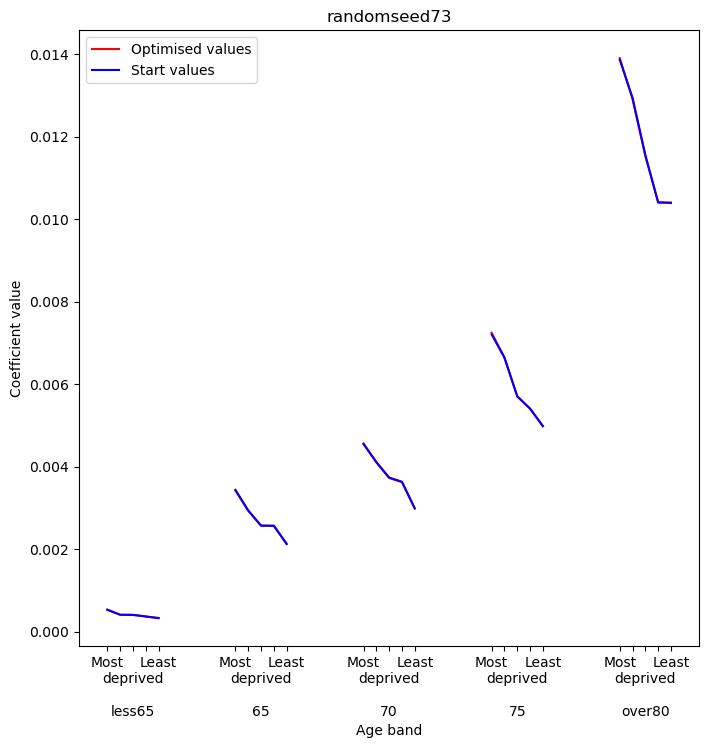

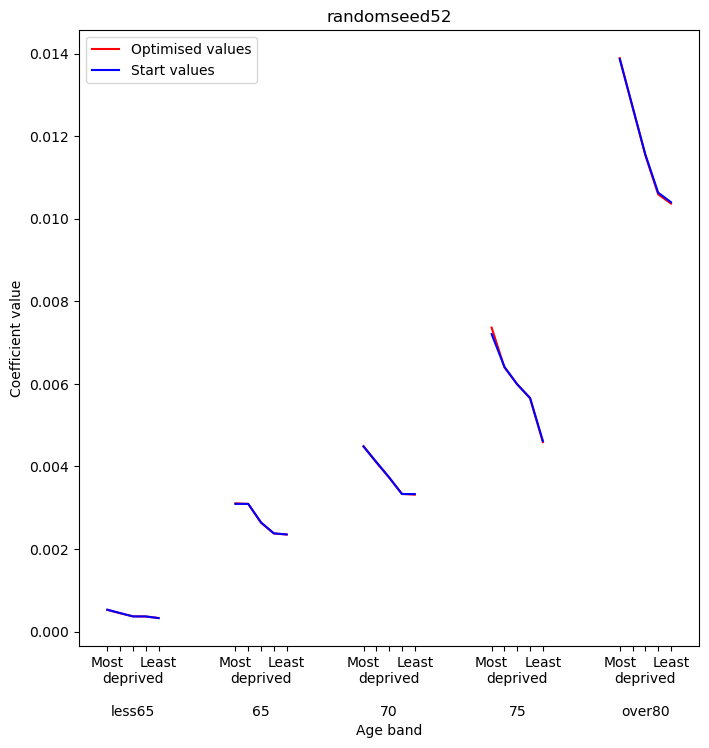

In [9]:
age_bands = ['less65', '65', '70', '75', 'over80']
x_offsets = np.arange(-0.2, 0.3, 0.1)
xticks_minor = np.concatenate([x_offsets + a for a in range(len(age_bands))])

qmin_labels = np.concatenate([['Most', '', '' + '\ndeprived\n\n' + age_band, '', 'Least'] for age_band in age_bands])

for coeff_combo in df_results['coeff_combo']:
    fig, ax = plt.subplots(figsize=(8, 8))

    for a, age in enumerate(age_bands):
        coeff_names_here = [c for c in df_results.columns if c.startswith(f'age_{age}')]
        
        ax.plot(x_offsets + a, df_results.filter(df_results['coeff_combo'] == coeff_combo)[coeff_names_here].to_numpy().flatten(), color='r', label=('Optimised values' if a == 0 else None))
        ax.plot(x_offsets + a, df_coeffs_init.filter(df_coeffs_init['coeff_combo'] == coeff_combo)[coeff_names_here].to_numpy().flatten(), color='b', label=('Start values' if a == 0 else None))
        
    # ax.set_xticks(np.arange(len(age_bands)))
    # ax.set_xticks(xticks_minor, minor=True)
    # ax.set_xticklabels(age_bands)
    ax.set_xticks(xticks_minor)
    ax.set_xticklabels(qmin_labels)
    
    ax.legend()
    ax.set_title(coeff_combo)
    ax.set_xlabel('Age band')
    ax.set_ylabel('Coefficient value')
    plt.show()

Optimised values haven't changed much from the inputs, so assume that these are local minima rather than global. Rely on the annealing results instead.

### View post-annealing results

View results:

In [10]:
df_ann_results.sort('r2_all', descending=True)

coeff_combo,message,success,nit,minimization_failures,nfev,age_less65_q00,age_65_q00,age_70_q00,age_75_q00,age_over80_q00,age_less65_q02,age_65_q02,age_70_q02,age_75_q02,age_over80_q02,age_less65_q04,age_65_q04,age_70_q04,age_75_q04,age_over80_q04,age_less65_q06,age_65_q06,age_70_q06,age_75_q06,age_over80_q06,age_less65_q08,age_65_q08,age_70_q08,age_75_q08,age_over80_q08,r2_q00,r2_q02,r2_q04,r2_q06,r2_q08,r2_all,res
str,str,bool,i64,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""randomseed37""","""requested number of basinhoppi…",true,100,0,114996,0.0005416,0.0040854,0.0053623,0.0070474,0.0123538,0.0004541,0.0027258,0.004313,0.0065205,0.0121114,0.0003801,0.0024998,0.0035562,0.0059555,0.011519,0.000366,0.0022614,0.0031576,0.0055009,0.0113243,0.000288,0.0021717,0.0029441,0.004876,0.0110193,0.50569,0.57875,0.63696,0.61852,0.62561,0.59714,236.386
"""randomseed22""","""requested number of basinhoppi…",true,100,0,113730,0.0005482,0.0037237,0.0047454,0.0072249,0.0131199,0.0004497,0.0030521,0.0042294,0.0061456,0.0122599,0.0003727,0.0027684,0.003502,0.0058283,0.0115918,0.0003548,0.0023756,0.0033697,0.0055355,0.0109173,0.0003043,0.0017906,0.0032337,0.0051244,0.010788,0.50519,0.57952,0.63792,0.61792,0.62383,0.59695,236.439
"""randomseed77""","""requested number of basinhoppi…",true,100,0,113780,0.0005391,0.0034591,0.0053,0.0075987,0.0127074,0.0004639,0.0030176,0.004719,0.0061441,0.0120112,0.0003847,0.0027691,0.0033765,0.0058385,0.0116627,0.0003561,0.0023192,0.0030874,0.0052843,0.0113105,0.0002849,0.0020781,0.0029117,0.0051419,0.0107714,0.50557,0.57859,0.63728,0.61892,0.62395,0.59691,236.451
"""randomseed08""","""requested number of basinhoppi…",true,100,0,115639,0.0005406,0.0037348,0.0047856,0.0074043,0.0129737,0.0004283,0.0032439,0.0043756,0.0063971,0.0121575,0.0003909,0.0025508,0.0035817,0.0057149,0.0115907,0.000365,0.0021945,0.0033611,0.0056175,0.0111307,0.0003078,0.0020173,0.0030329,0.0048528,0.010744,0.50541,0.58125,0.63642,0.61795,0.62246,0.59675,236.499
"""randomseed92""","""requested number of basinhoppi…",true,100,0,114798,0.0005244,0.0036943,0.0054679,0.0081789,0.0125169,0.0004549,0.002744,0.0039637,0.0066886,0.0122908,0.0003961,0.0026023,0.0036067,0.0056538,0.0115864,0.0003725,0.0024379,0.0032022,0.0050033,0.011178,0.0002838,0.0021721,0.0030508,0.0048398,0.0108762,0.50657,0.5787,0.63595,0.61764,0.6249,0.59675,236.5
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""randomseed56""","""requested number of basinhoppi…",true,100,0,118982,0.0005075,0.0042641,0.0043401,0.0079003,0.0134106,0.0004333,0.0027055,0.0041487,0.0065108,0.0128338,0.0003905,0.0023633,0.003909,0.0064556,0.011255,0.0003872,0.0022525,0.0033526,0.0050597,0.0109883,0.0003189,0.0021953,0.0031935,0.0043619,0.0104282,0.50799,0.58173,0.63557,0.61639,0.61757,0.59587,236.757
"""randomseed65""","""requested number of basinhoppi…",true,100,0,118748,0.0005472,0.0031814,0.0048562,0.0078638,0.0133847,0.0004466,0.0031691,0.004075,0.0056192,0.0129806,0.0004048,0.0030099,0.0037677,0.0054948,0.0111652,0.0003687,0.002206,0.0032449,0.0054896,0.0109749,0.0002612,0.0020424,0.0031617,0.0054726,0.0104288,0.50511,0.58112,0.6332,0.61749,0.62239,0.59585,236.764
"""randomseed47""","""requested number of basinhoppi…",true,100,0,114779,0.0005722,0.0031178,0.0042797,0.0079585,0.0130955,0.0004959,0.0029512,0.0040717,0.0061893,0.0119295,0.0003767,0.0026431,0.0040027,0.0055668,0.0115258,0.0002947,0.0024613,0.0035569,0.0054514,0.0111378,0.0002802,0.0023702,0.0029985,0.0049712,0.0108853,0.50182,0.57445,0.63746,0.61866,0.6257,0.59573,236.797


View all post-annealing coefficient sets:

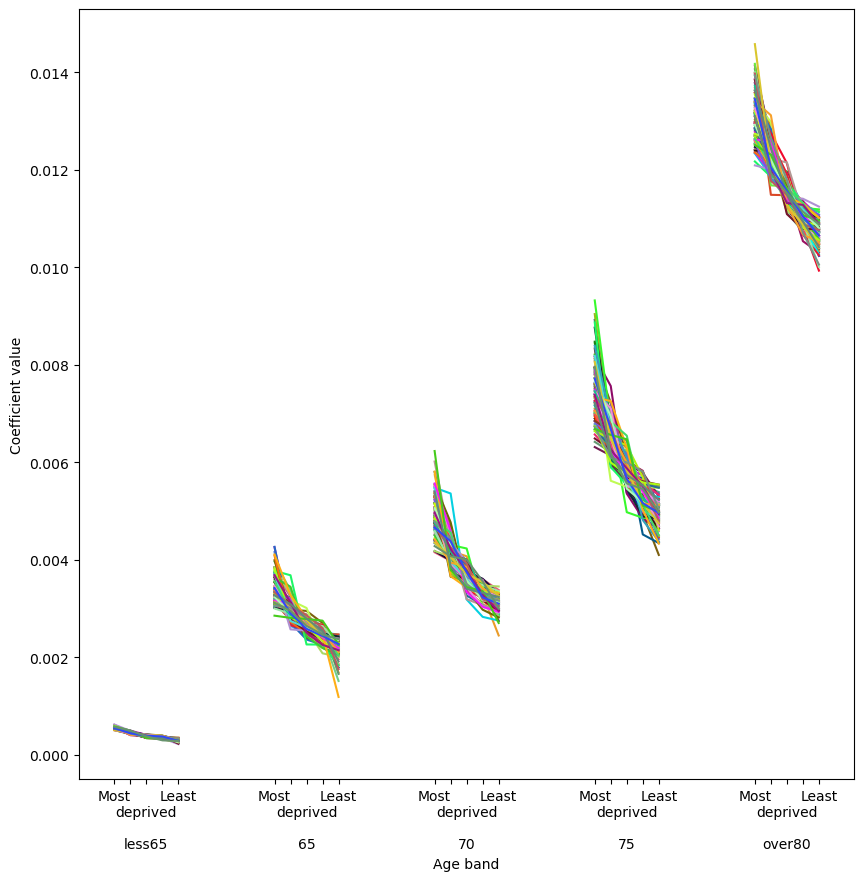

In [11]:
age_bands = ['less65', '65', '70', '75', 'over80']
x_offsets = np.arange(-0.2, 0.3, 0.1)
xticks_minor = np.concatenate([x_offsets + a for a in range(len(age_bands))])
qmin_labels = np.concatenate([['Most', '', '' + '\ndeprived\n\n' + age_band, '', 'Least'] for age_band in age_bands])

fig, ax = plt.subplots(figsize=(10, 10))

# colours = ['b', 'r']
# labels = ['DEAP', 'DEAP then anneal']

for results_dir in df_ann_results['coeff_combo']:
    # Pick out coeffs:
    # coeffs = df_best_gens.filter(df_best_gens['dir'] == results_dir)[coeff_names].to_numpy().flatten()
    coeffs_ann = df_ann_results.filter(df_ann_results['coeff_combo'] == results_dir)[coeff_names].to_numpy().flatten()
    # for i, coeffs in enumerate([coeffs, coeffs_ann]):
    for i, coeffs in enumerate([coeffs_ann]):
        # if results_dir in df_best_gens_topr2['dir']:
        colour = np.random.rand(3,)
        # colour = colours[i]
        zorder = 5
        alpha = 1.0
        # else:
        #     colour = 'silver'
        #     zorder = 4
        #     alpha = 0.4
        # g = gen_attr(df_coeffs_init)
    
        offset = -0.2
        for c in range(5):
            # xs = np.arange(5) + offset
            # ys = g[c*5:(c*5)+5]
            xs = x_offsets + c
            
            ys = np.array(coeffs)[np.arange(0, 25, 5) + c]
            ax.plot(xs, ys, color=colour, zorder=zorder, alpha=alpha, 
                    # label=labels[i] if c < 1 else None)
                    label=(results_dir if c==0 else None))
            offset += 0.1
        
ax.set_xticks(xticks_minor)
ax.set_xticklabels(qmin_labels)
ax.set_xlabel('Age band')
ax.set_ylabel('Coefficient value')
# ax.legend()

plt.show()

In [12]:
coeffs_ann

array([0.0005722, 0.0031178, 0.0042797, 0.0079585, 0.0130955, 0.0004959,
       0.0029512, 0.0040717, 0.0061893, 0.0119295, 0.0003767, 0.0026431,
       0.0040027, 0.0055668, 0.0115258, 0.0002947, 0.0024613, 0.0035569,
       0.0054514, 0.0111378, 0.0002802, 0.0023702, 0.0029985, 0.0049712,
       0.0108853])

Still seeing a range in final coefficients. Haven't converged on one set of ``best'' coefficients from all of the different starting points.

Plot starting vs optimised values for the same subset as the `minimize` results:

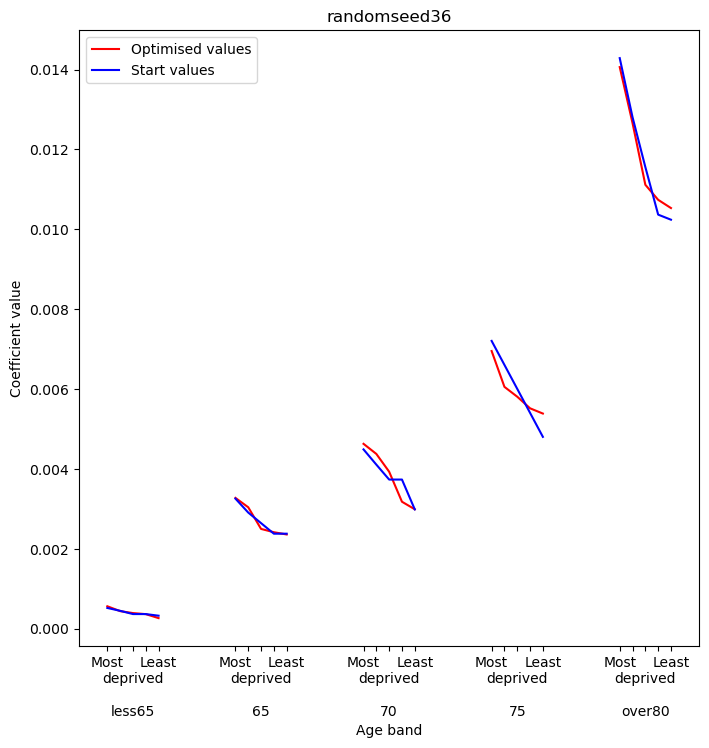

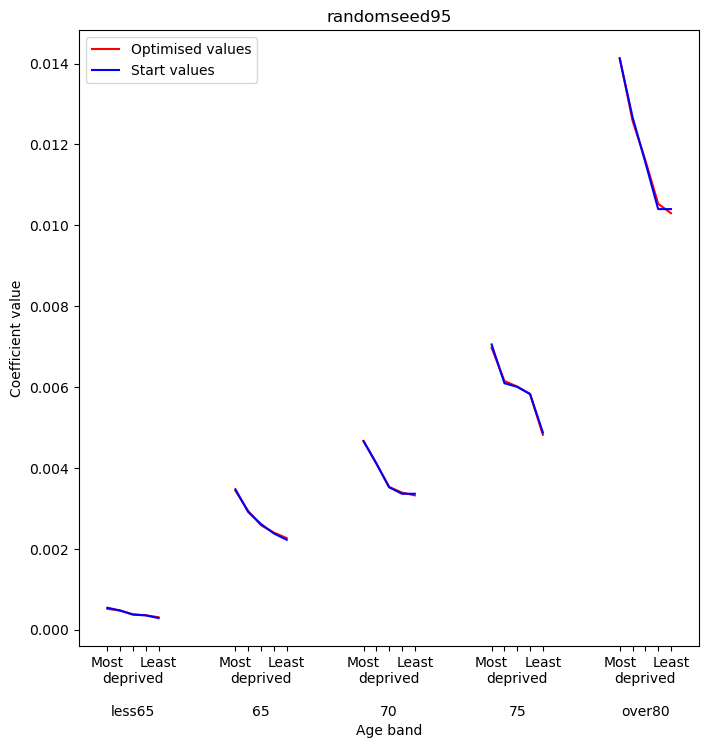

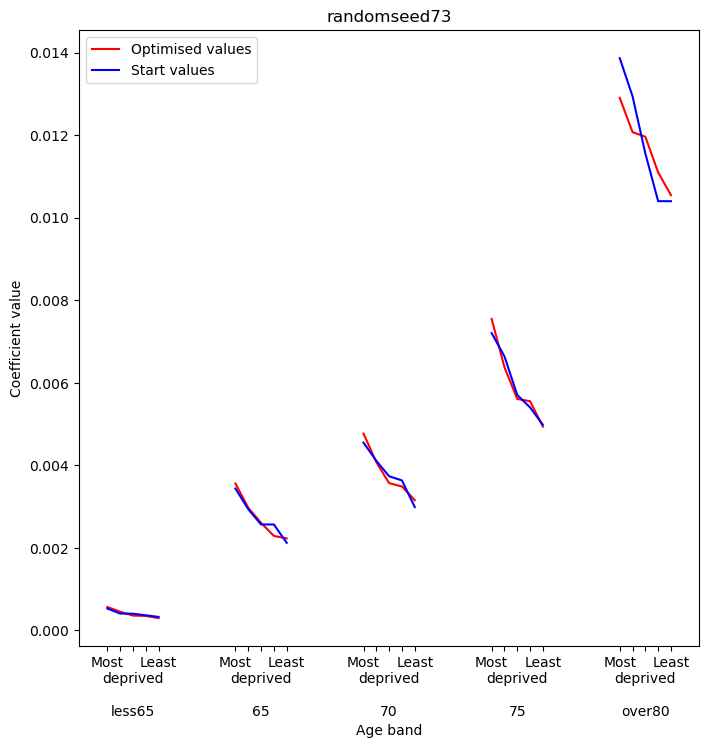

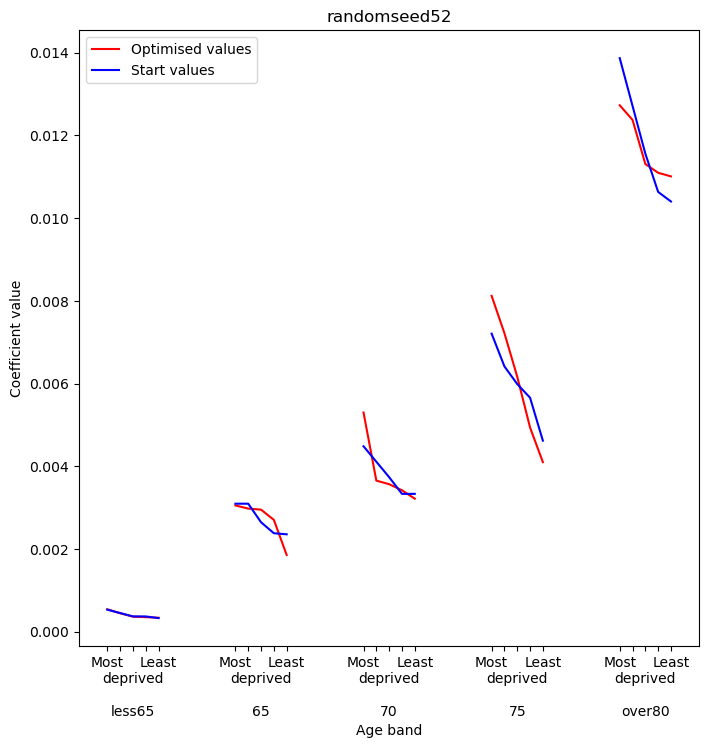

In [13]:
age_bands = ['less65', '65', '70', '75', 'over80']
x_offsets = np.arange(-0.2, 0.3, 0.1)
xticks_minor = np.concatenate([x_offsets + a for a in range(len(age_bands))])

qmin_labels = np.concatenate([['Most', '', '' + '\ndeprived\n\n' + age_band, '', 'Least'] for age_band in age_bands])

for coeff_combo in df_results['coeff_combo']:
    fig, ax = plt.subplots(figsize=(8, 8))

    for a, age in enumerate(age_bands):
        coeff_names_here = [c for c in df_ann_results.columns if c.startswith(f'age_{age}')]
        
        ax.plot(x_offsets + a, df_ann_results.filter(df_ann_results['coeff_combo'] == coeff_combo)[coeff_names_here].to_numpy().flatten(), color='r', label=('Optimised values' if a == 0 else None))
        ax.plot(x_offsets + a, df_coeffs_init.filter(df_coeffs_init['coeff_combo'] == coeff_combo)[coeff_names_here].to_numpy().flatten(), color='b', label=('Start values' if a == 0 else None))
        
    # ax.set_xticks(np.arange(len(age_bands)))
    # ax.set_xticks(xticks_minor, minor=True)
    # ax.set_xticklabels(age_bands)
    ax.set_xticks(xticks_minor)
    ax.set_xticklabels(qmin_labels)
    
    ax.legend()
    ax.set_title(coeff_combo)
    ax.set_xlabel('Age band')
    ax.set_ylabel('Coefficient value')
    plt.show()

Seeing more difference from the starting values this time so have more trust that these derived coefficients are actually optimised.

### Pick out best result

Pick out only the coefficient sets whose r-squared value matches the best:

In [14]:
mask = np.round(df_ann_results['r2_all'], 4) == np.round(df_ann_results['r2_all'].max(), 4)

df_best_ann = df_ann_results.filter(mask)#[coeff_names]

In [15]:
df_best_ann

coeff_combo,message,success,nit,minimization_failures,nfev,age_less65_q00,age_65_q00,age_70_q00,age_75_q00,age_over80_q00,age_less65_q02,age_65_q02,age_70_q02,age_75_q02,age_over80_q02,age_less65_q04,age_65_q04,age_70_q04,age_75_q04,age_over80_q04,age_less65_q06,age_65_q06,age_70_q06,age_75_q06,age_over80_q06,age_less65_q08,age_65_q08,age_70_q08,age_75_q08,age_over80_q08,r2_q00,r2_q02,r2_q04,r2_q06,r2_q08,r2_all,res
str,str,bool,i64,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""randomseed37""","""requested number of basinhoppi…",true,100,0,114996,0.0005416,0.0040854,0.0053623,0.0070474,0.0123538,0.0004541,0.0027258,0.004313,0.0065205,0.0121114,0.0003801,0.0024998,0.0035562,0.0059555,0.011519,0.000366,0.0022614,0.0031576,0.0055009,0.0113243,0.000288,0.0021717,0.0029441,0.004876,0.0110193,0.50569,0.57875,0.63696,0.61852,0.62561,0.59714,236.386


Only one set of coefficients!

Compare with start values:

In [16]:
best_ann_dir = df_ann_results.filter(mask)['coeff_combo'][0]

df_coeffs_init.filter(df_coeffs_init['coeff_combo'] == best_ann_dir)

coeff_combo,age_less65_q00,age_65_q00,age_70_q00,age_75_q00,age_over80_q00,age_less65_q02,age_65_q02,age_70_q02,age_75_q02,age_over80_q02,age_less65_q04,age_65_q04,age_70_q04,age_75_q04,age_over80_q04,age_less65_q06,age_65_q06,age_70_q06,age_75_q06,age_over80_q06,age_less65_q08,age_65_q08,age_70_q08,age_75_q08,age_over80_q08
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""randomseed37""",0.0004896,0.0031728,0.004482,0.00711,0.015083,0.0004488,0.002641,0.0041085,0.006503,0.013176,0.000406,0.002641,0.003735,0.006143,0.011304,0.0003672,0.002641,0.0033615,0.00538,0.0104022,0.0003264,0.002337,0.003272,0.004804,0.009697


View range of resulting coefficients:

In [17]:
df_max = df_ann_results.max()[coeff_names]
df_min = df_ann_results.min()[coeff_names]
df_range = df_max - df_min

df = pl.concat((df_min, df_max, df_range, df_best_ann))

for col in coeff_names:
    if 'less65' in col:
        n = 4
    elif 'over80' in col:
        n = 3
    else:
        n = 3
    df = df.with_columns(pl.col(col).round(n))

df * 100.0

ShapeError: unable to append to a DataFrame of width 25 with a DataFrame of width 38

View just the best coefficients:

In [ ]:
(df_best_ann * 100.0).to_numpy().reshape(5, 5)

View just the best coefficients, rounded, and the minimum and maximum values seen:

In [ ]:
for df in df_best_ann, df_min, df_max:
    
    for col in coeff_names:
        if 'less65' in col:
            n = 4
        elif 'over80' in col:
            n = 3
        else:
            n = 3
        df = df.with_columns(pl.col(col).round(n))
    
    display((df * 100.0).to_numpy().reshape(5, 5))

Save a copy of the best coefficients:

In [ ]:
age_labels = {
    'less65': 'less65',
    '65': '65-70',
    '70': '70-75',
    '75': '75-80',
    'over80': 'over80',
}

In [ ]:
qmin_list = np.round(np.arange(0.0, 1.0, 0.2), 1)

In [ ]:
dfs_to_save_dict = {
    'best': df_best_ann,
    'min': df_min,
    'max': df_max,
}

dfs_to_save = []

for label, df in dfs_to_save_dict.items(): 
    df_to_save = (df).to_numpy().reshape(5, 5)
    
    # df_to_save = np.hstack((np.array(['00_most', '02', '04', '06', '08_least']).reshape(5, 1), df_to_save))
    df_to_save = np.hstack((np.array(qmin_list).reshape(5, 1), df_to_save))
    df_to_save = np.hstack((np.array([label]*5).reshape(5, 1), df_to_save))
    
    age_cols = list(age_labels.values())  #[f'age_{a}' for a in age_bands]
    df_to_save = pl.DataFrame(df_to_save, schema=['coeff_set', 'depriv_quantile_min'] + age_cols)
    
    # Convert coeff columns to float:
    df_to_save = df_to_save.cast(dict(zip(age_cols, [float]*len(age_cols))))
    df_to_save = df_to_save.cast(dict(depriv_quantile_min=float))
    # Round values again to prevent floating point error:
    for col in age_cols:
        if 'less65' in col:
            n = 4
        elif 'over80' in col:
            n = 3
        else:
            n = 3
        df_to_save = df_to_save.with_columns(pl.col(col).round(n))
    df_to_save = df_to_save.with_columns(pl.col('depriv_quantile_min').round(1))
    dfs_to_save.append(df_to_save)

df_to_save = pl.concat(dfs_to_save)

In [ ]:
with pl.Config(tbl_rows=15):
    display(df_to_save)

In [ ]:
df_to_save.write_csv(os.path.join('outputs', 'coeffs_prob_stroke_given_age_depriv.csv'))

In [ ]:
import polars as pl
import os

In [ ]:
df_final_coeffs = pl.read_csv(os.path.join('outputs', 'coeffs_prob_stroke_given_age_depriv.csv'))

In [ ]:
df_final_coeffs

In [ ]:
qmin_list = sorted(df_final_coeffs['depriv_quantile_min'].unique())

In [ ]:
age_cols = ['less65', '65-70', '70-75', '75-80', 'over80']

In [ ]:
df_final_coeffs_best = df_final_coeffs.filter(df_final_coeffs['coeff_set'] == 'best')
df_final_coeffs_min = df_final_coeffs.filter(df_final_coeffs['coeff_set'] == 'min')
df_final_coeffs_max = df_final_coeffs.filter(df_final_coeffs['coeff_set'] == 'max')

In [ ]:
q_labels = {
    0.0: '0% to 20% (most deprived)',
    0.2: '20% to 40%',
    0.4: '40% to 60%',
    0.6: '60% to 80%',
    0.8: '80% to 100% (least deprived)'
    }

In [ ]:
print('| Deprivation quantile | Under 65 | 65 to 69 | 70 to 74 | 75 to 80 | Over 80 |')
print('| --- | --- | --- | --- | --- | --- |')
for q, qmin in enumerate(qmin_list):
    q_str = q_labels[qmin]
    row = f'| {q_str} |'
    for age_col in age_cols:
        coeff_best = df_final_coeffs_best.filter(df_final_coeffs_best['depriv_quantile_min'] == qmin)[age_col].to_numpy()[0]
        coeff_min = df_final_coeffs_min.filter(df_final_coeffs_best['depriv_quantile_min'] == qmin)[age_col].to_numpy()[0]
        coeff_max = df_final_coeffs_max.filter(df_final_coeffs_best['depriv_quantile_min'] == qmin)[age_col].to_numpy()[0]
        row += f' {round(100.0*coeff_best, 6)}% ({round(100.0*coeff_min, 6)}%--{round(100.0*coeff_max, 6)}%) |'
    print(row)